In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, w_object, patch_creation, get_patch_data, bbox_props
modify_rc()
modify_rc()
from src import synthesize


In [2]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)

sky6 = sm.Sky(nside=NSIDE, preset_strings=['s6'])

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [3]:
t0, e0, b0 = hp.alm2map(sky6.components[0].template_largescale_alm.value, NSIDE, pol=False)
cls0 = hp.anafast([t0, e0, b0], lmax=LMAX, pol=False)
cl_t0, cl_e0, cl_b0, cl_te0 = cls0[0], cls0[1], cls0[2], cls0[3]

In [4]:
mod_mapI = hp.alm2map(sky6.components[0].modulate_alm[0].value, NSIDE)
mod_mapP = hp.alm2map(sky6.components[0].modulate_alm[1].value, NSIDE)

In [5]:
cl_tt = sky6.components[0].small_scale_cl[0][:LMAX+1].value
cl_tt[cl_tt == 0.] = 1e-15
cl_ee = sky6.components[0].small_scale_cl[1][:LMAX+1].value
cl_ee[cl_ee == 0.] = 1e-15
cl_bb = sky6.components[0].small_scale_cl[2][:LMAX+1].value
cl_bb[cl_bb == 0.] = 1e-15
cl_te = sky6.components[0].small_scale_cl[3][:LMAX+1].value
cl_te[cl_te == 0.] = 1e-15

cl_tt = np.float64(cl_tt)
cl_ee = np.float64(cl_ee)
cl_bb = np.float64(cl_bb)
cl_te = np.float64(cl_te)

/tmp/ipykernel_64972/3675592422.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_tt = np.float64(cl_tt)
/tmp/ipykernel_64972/3675592422.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_ee = np.float64(cl_ee)
/tmp/ipykernel_64972/3675592422.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_bb = np.float64(cl_bb)
/tmp/ipykernel_64972/3675592422.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  cl_te = np.float64(cl_te)


In [6]:
import kea
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum
FEKS_TT = []
FEKS_EE = []
FEKS_BB = []
FEKS_TE = []

In [7]:
L_CENTER = 318.0
B_CENTER = -61.0

In [8]:
C_VAL = 0.00001
LAMBDA_VAL = 0.00001
LARGE_C = 0.00001

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS = np.zeros((5, 5, np.shape(img)[0], np.shape(img)[1]))
IMGS[0,0,:,:] = img
IMGS_DELTA = np.zeros((5, 5, np.shape(img)[0], np.shape(img)[1]))
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,0,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [9]:
C_VAL = 0.00001
LAMBDA_VAL = 0.1
LARGE_C = 0.00001

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,1,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,1,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


<unknown>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<unknown>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [10]:
C_VAL = 0.00001
LAMBDA_VAL = 0.25
LARGE_C = 0.00001

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,2,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,2,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [11]:
C_VAL = 0.00001
LAMBDA_VAL = 0.5
LARGE_C = 0.00001

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[0,3,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[0,3,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [12]:
C_VAL = 1.0
LAMBDA_VAL = 0.00001
LARGE_C = 1.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[1,0,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[1,0,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [13]:
C_VAL = 1.0
LAMBDA_VAL = 0.1
LARGE_C = 1.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[1,1,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[1,1,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [14]:
C_VAL = 1.0
LAMBDA_VAL = 0.25
LARGE_C = 1.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[1,2,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[1,2,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [15]:
C_VAL = 1.0
LAMBDA_VAL = 0.5
LARGE_C = 1.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[1,3,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[1,3,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [16]:
C_VAL = 5.0
LAMBDA_VAL = 0.00001
LARGE_C = 2.5

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[2,0,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[2,0,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [17]:
C_VAL = 5.0
LAMBDA_VAL = 0.1
LARGE_C = 2.5

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[2,1,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[2,1,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [18]:
C_VAL = 5.0
LAMBDA_VAL = 0.25
LARGE_C = 2.5

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[2,2,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[2,2,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [19]:
C_VAL = 5.0
LAMBDA_VAL = 0.5
LARGE_C = 2.5

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[2,3,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[2,3,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [20]:
C_VAL = 10.0
LAMBDA_VAL = 0.00001
LARGE_C = 5.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[3,0,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[3,0,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [21]:
C_VAL = 10.0
LAMBDA_VAL = 0.1
LARGE_C = 5.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[3,1,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[3,1,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [22]:
C_VAL = 10.0
LAMBDA_VAL = 0.25
LARGE_C = 5.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[3,2,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[3,2,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


In [23]:
C_VAL = 10.0
LAMBDA_VAL = 0.5
LARGE_C = 5.0

t_delta_params = ({
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
},{
    'cl_target': cl_tt,
    'cl_noise': cl_tt,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[0],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapI,
})
e_delta_params = ({
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target': cl_ee,
    'cl_noise':cl_ee,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[1],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})
b_delta_params = ({
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'isotropic',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
},{
    'cl_target':cl_bb,
    'cl_noise':cl_bb,
    'c':C_VAL,
    'lambda':LAMBDA_VAL,
    'anisotropy':'meridional',
    'large_alm':sky6.components[0].template_largescale_alm.value[2],
    'large_c_param': LARGE_C,
    'mod_map': mod_mapP,
})

i_delta_ls, q_delta_ls, u_delta_ls = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
I_ref, Q_ref, U_ref = synthesize.make_IQU_ref(i_delta_ls, q_delta_ls, u_delta_ls)
T_ref, E_ref, B_ref = hp.alm2map(hp.map2alm((I_ref, Q_ref, U_ref), pol=True), pol=False, nside=NSIDE)

l_high, b_high, img = get_patch_data(np.sqrt(Q_ref**2 + U_ref**2), l_center=L_CENTER, b_center=B_CENTER)
IMGS[3,3,:,:] = img
l_high, b_high, img = get_patch_data(i_delta_ls, l_center=L_CENTER, b_center=B_CENTER)
IMGS_DELTA[3,3,:,:] = img

l_high, b_high, imgT = get_patch_data(T_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgE = get_patch_data(E_ref, l_center=L_CENTER, b_center=B_CENTER)
l_high, b_high, imgB = get_patch_data(B_ref, l_center=L_CENTER, b_center=B_CENTER)
kvec, fek = fourier_modal_spectrum(imgT)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TT.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_EE.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgB)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_BB.append((k, fek))
kvec, fek = fourier_modal_spectrum(imgT, imgE)
k, fek, _ = bin_spectrum(kvec, fek, 'integrated')
FEKS_TE.append((k, fek))


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:683: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.real[i] = almr
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/fitsfunc.py:684: ComplexWarning: Casting complex values to real discards the imaginary part
  alm.imag[i] = almi


generating monofractal field


/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  (np.asarray(cl, dtype=np.float64) if cl is not None else None)
/home/mark.bishop/miniconda3/envs/pysm/lib/python3.14/site-packages/healpy/sphtfunc.py:1363: ComplexWarning: Casting complex values to real discards the imaginary part
  cls_list = [np.asarray(cls, dtype=np.float64)]


<>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:88: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:88: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_64972/3892021969.py:61: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax[0][j].set_title(f'$\lambda={lambdas[j]}$', fontsize=8.)
/tmp/ipykernel_64972/3892021969.py:88: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did

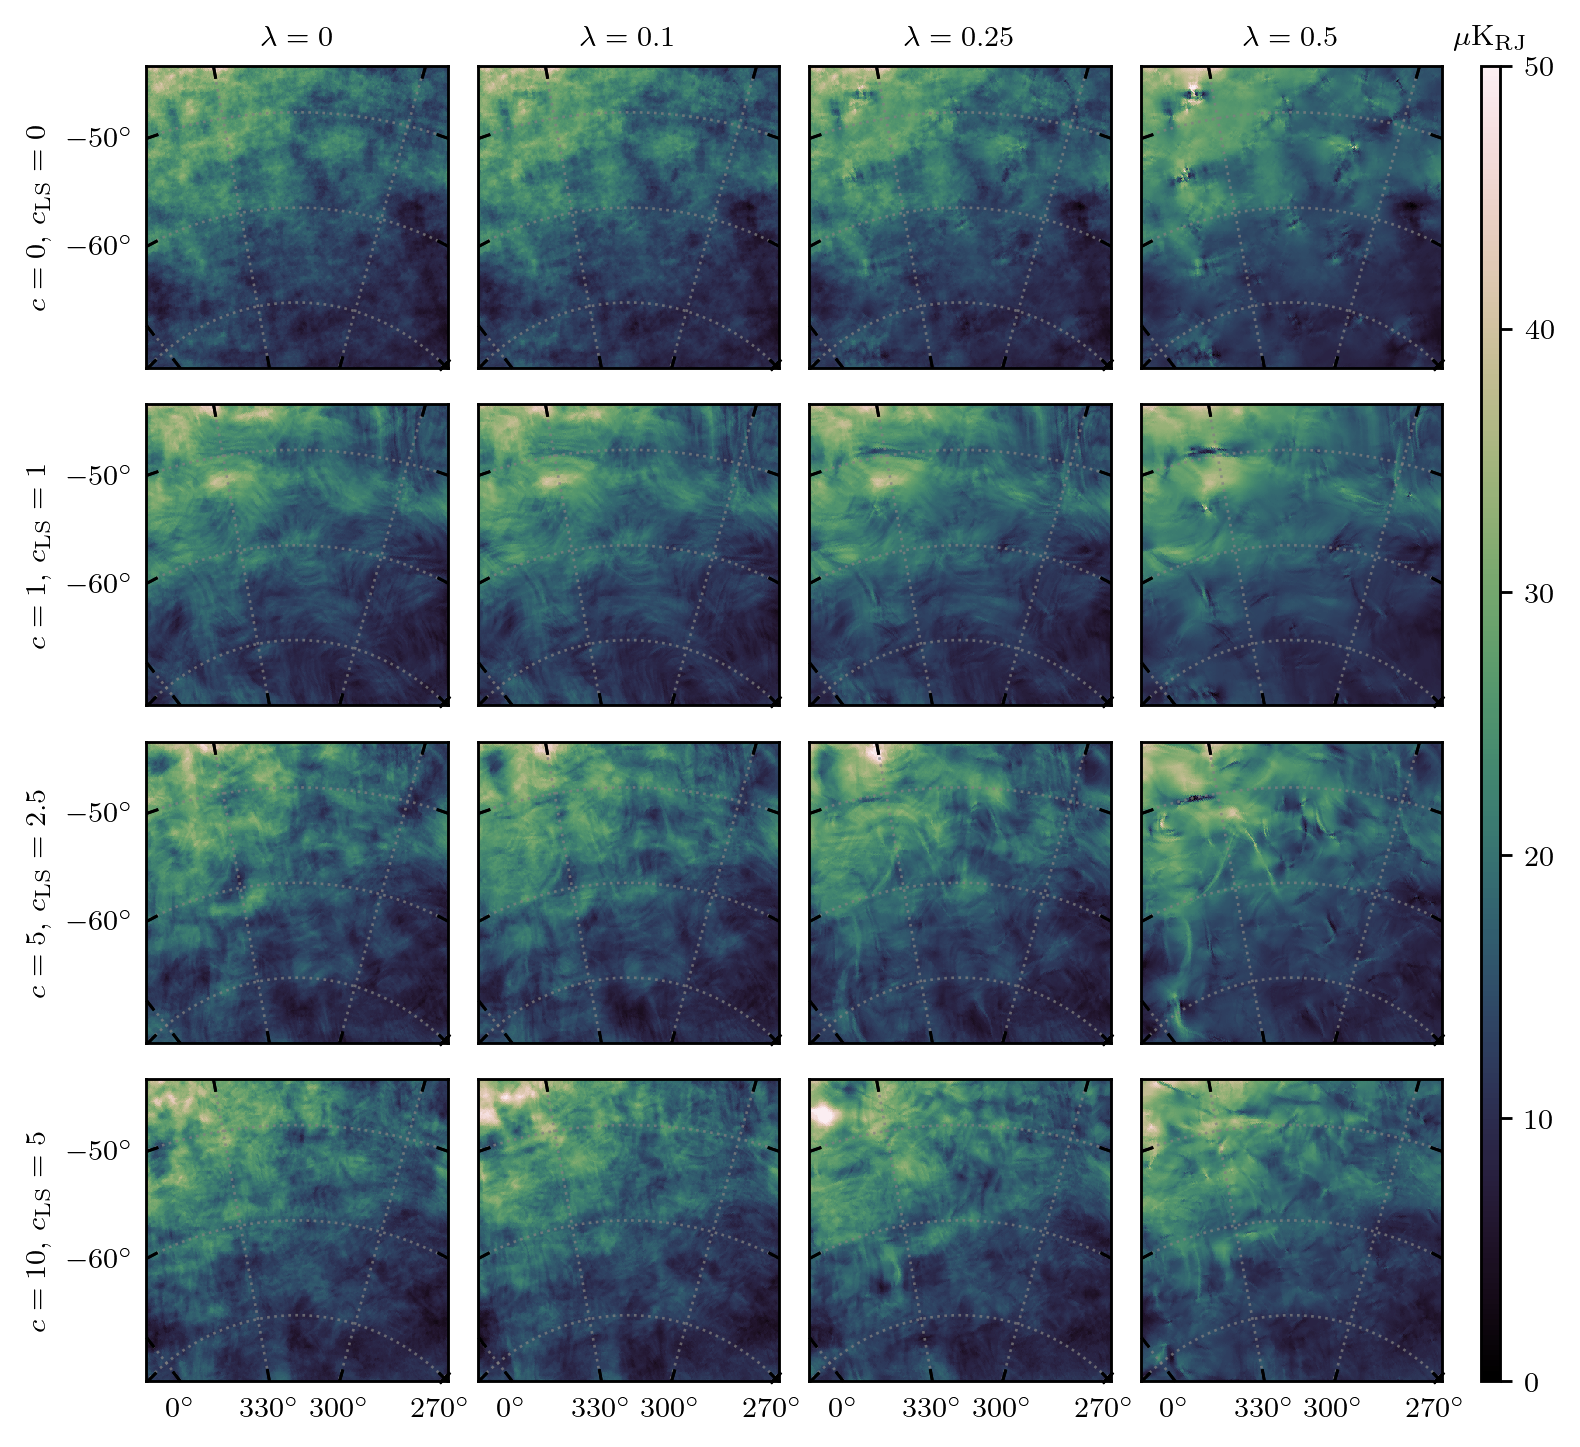

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

# 1. Define the parameters from your get_patch_data extraction
# Assuming these variables exist in your script:
# l_center, b_center, res_arcmin
xsize = IMGS.shape[-1] # The pixel width/height of the patches


# 2. Construct the World Coordinate System (WCS) for a Gnomonic (TAN) projection
w = WCS(naxis=2)
w.wcs.crpix = [xsize / 2.0 + 0.5, xsize / 2.0 + 0.5]  # Center pixel of the image
w.wcs.crval = [L_CENTER, B_CENTER]                    # Coordinate at the center pixel

# WCS standard for resolution (CDELT): 
# Longitude conventionally decreases to the right (East is left), hence negative.
# Note: If your image appears upside down due to hp.gnomview's array ordering, 
# you may need to flip the sign of the latitude CDELT or change origin='upper'.
w.wcs.cdelt = np.array([-4.94 / 60.0, 4.94 / 60.0])
w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"] # Galactic Longitude/Latitude, Tangent (Gnomonic) projection

# 3. Create figure and grid with the WCS projection
fig = plt.figure(figsize=(7.5, 7.5), dpi=256)

# Create axes dynamically with the WCS projection attached
ax = [[fig.add_subplot(4, 4, i*4 + j + 1, projection=w) for j in range(4)] for i in range(4)]

pol_cmap = sns.cubehelix_palette(start=0.5, rot=-0.95, dark=0.0, light=0.95, as_cmap=True, reverse=True)

# Loop through to plot images and set up grids
for i in range(4):
    for j in range(4):
        # NOTE: No 'extent' argument! WCS maps the pixels to l,b natively.
        im = ax[i][j].imshow(IMGS[i, j], cmap=pol_cmap, origin='lower', 
                             interpolation='none', vmin=0., vmax=50.)
        
        # --- THIS IS THE MAGIC LINE ---
        # Draw the curved coordinate grid lines
        ax[i][j].coords.grid(color='white', alpha=0.4, linestyle='dashed')
        
        # WCSAxes handles ticks differently than standard matplotlib axes
        lon = ax[i][j].coords[0]
        lat = ax[i][j].coords[1]
        
        # Apply your aesthetic tweaks
        # pretty_axes(ax[i][j]) # You might need to adapt this function for WCSAxes
        
        # Hide tick labels for inner subplots (replacing set_xticklabels([]))
        if j > 0:
            lat.set_ticklabel_visible(False)
        if i < 3:
            lon.set_ticklabel_visible(False)

# 4. Set titles and labels
lambdas = ['0', '0.1', '0.25', '0.5']
cs = ['0', '1', '5', '10']
c_ls = ['0', '1', '2.5', '5']

for j in range(4):
    ax[0][j].set_title(f'$\lambda={lambdas[j]}$', fontsize=8.)
for i in range(4):
    # Depending on matplotlib version, WCSAxes ylabel might need specific placement
    ax[i][0].set_ylabel(r'$c=%s,\,c_\mathrm{LS}=%s$' % (cs[i], c_ls[i])) 

for axs in ax:
    for axx in axs:
        # pretty_axes(axx)
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
# --->    axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        # axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.75, linewidth=0.75, color='gray')
        axx.set_yticklabels([])
        axx.set_xticklabels([])

ax[3][0].set_xlabel('')
ax[3][1].set_xlabel('')
ax[3][2].set_xlabel('')
ax[3][3].set_xlabel('')

# 5. Adjust layout and add colorbar
fig.subplots_adjust(wspace=0.1, hspace=-0.275, right=0.8)
cbar_ax = fig.add_axes([0.82, 0.1525, 0.01, 0.685])
fig.colorbar(im, cax=cbar_ax)
cbar_ax.set_title('$\mu\mathrm{K}_\mathrm{RJ}$', fontsize=8.)

fig.savefig('plots/examples_iterate_pol.pdf', pad_inches=0.1, bbox_inches='tight')

<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_64972/1229550722.py:37: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax[0][j].set_title(f'$\lambda={lambdas[j]}$', fontsize=8.)


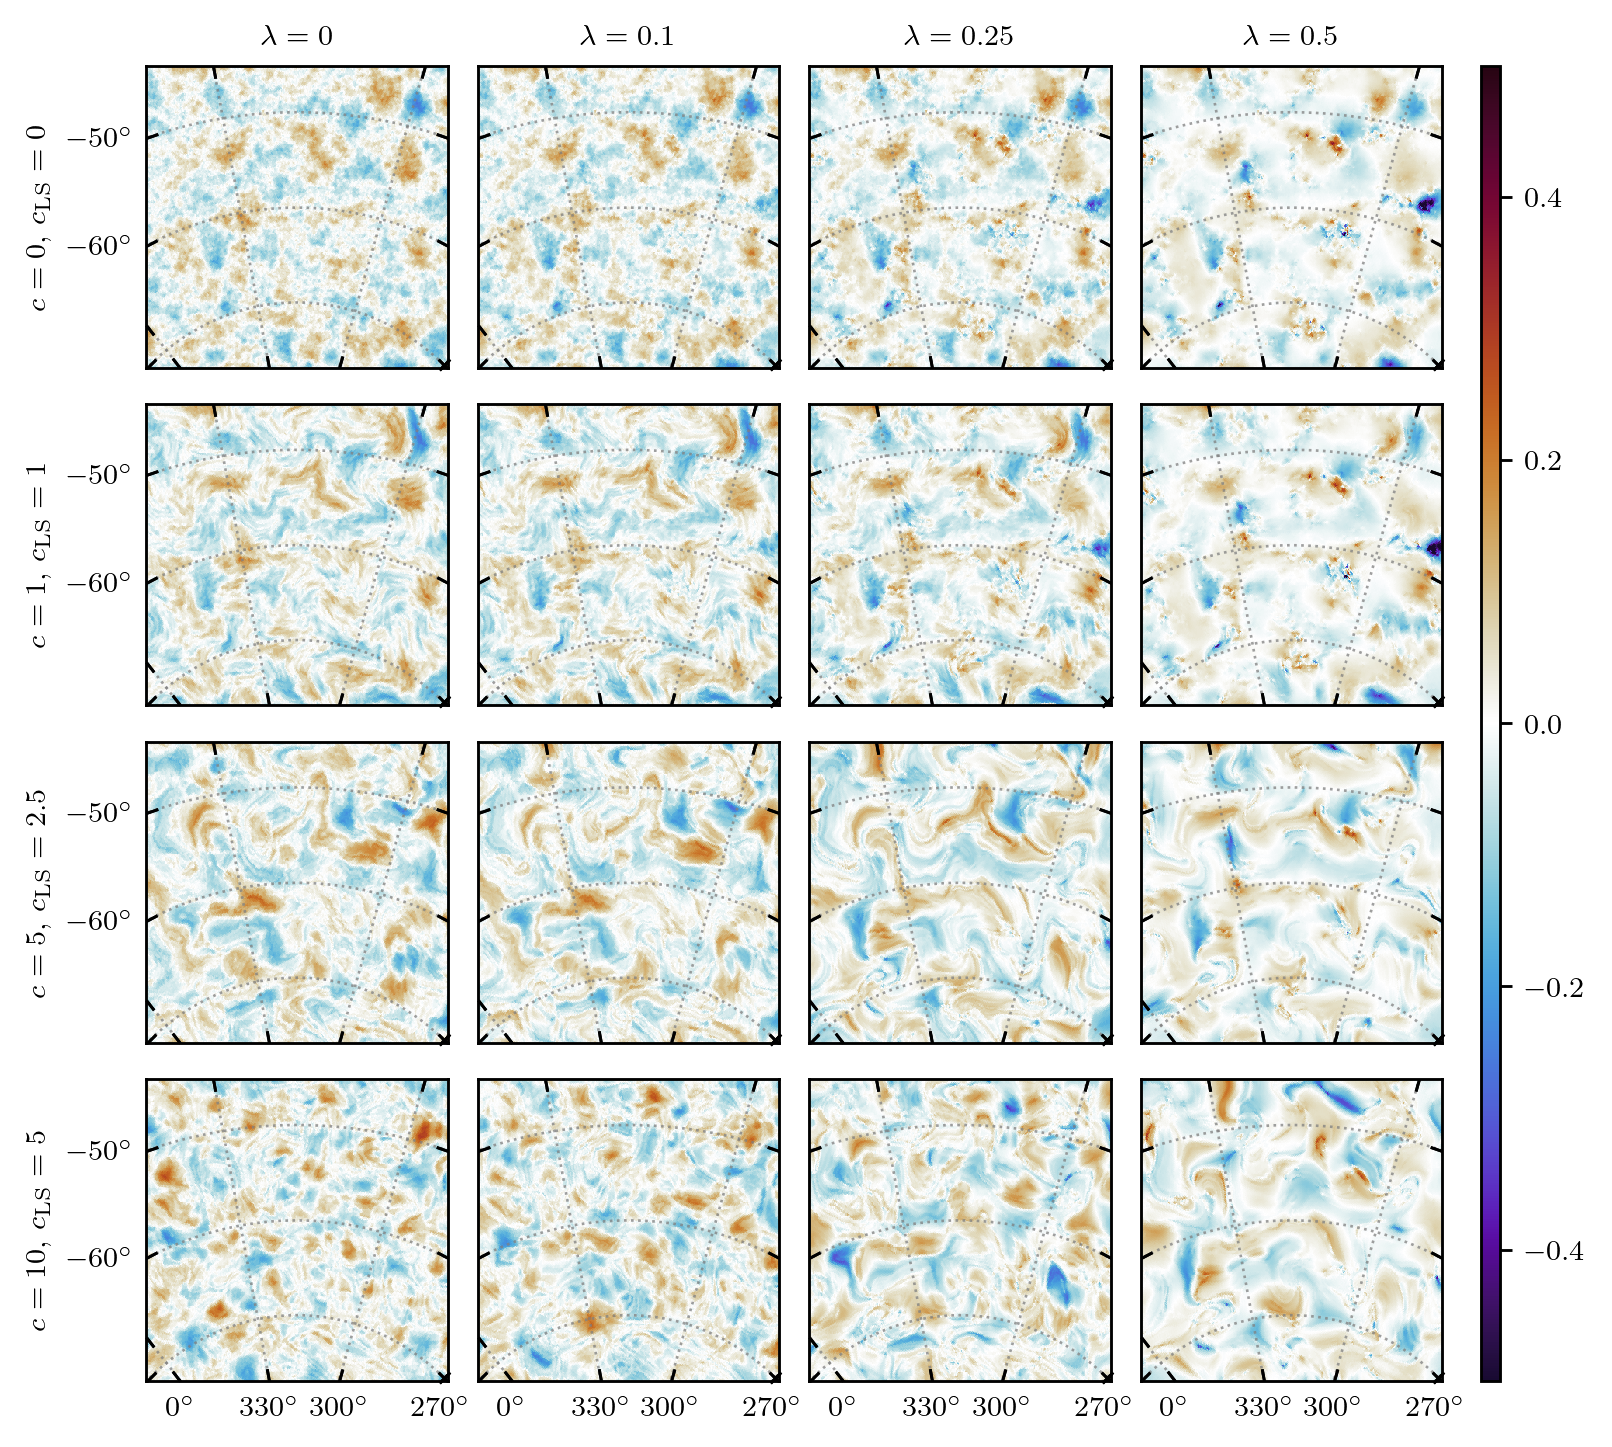

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.wcs import WCS

xsize = IMGS_DELTA.shape[-1] # The pixel width/height of the patches

w = WCS(naxis=2)
w.wcs.crpix = [xsize / 2.0 + 0.5, xsize / 2.0 + 0.5]  # Center pixel of the image
w.wcs.crval = [L_CENTER, B_CENTER]                    # Coordinate at the center pixel

w.wcs.cdelt = np.array([-4.94 / 60.0, 4.94 / 60.0])
w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"] # Galactic Longitude/Latitude, Tangent (Gnomonic) projection

fig = plt.figure(figsize=(7.5, 7.5), dpi=256)

ax = [[fig.add_subplot(4, 4, i*4 + j + 1, projection=w) for j in range(4)] for i in range(4)]

fusion_cmap = cmr.fusion_r

for i in range(4):
    for j in range(4):
        im = ax[i][j].imshow(IMGS_DELTA[i, j], cmap=fusion_cmap, origin='lower', 
                             interpolation='none', vmin=-0.5, vmax=0.5)
        ax[i][j].coords.grid(color='white', alpha=0.4, linestyle='dashed')
        lon = ax[i][j].coords[0]
        lat = ax[i][j].coords[1]
        if j > 0:
            lat.set_ticklabel_visible(False)
        if i < 3:
            lon.set_ticklabel_visible(False)

lambdas = ['0', '0.1', '0.25', '0.5']
cs = ['0', '1', '5', '10']
c_ls = ['0', '1', '2.5', '5']

for j in range(4):
    ax[0][j].set_title(f'$\lambda={lambdas[j]}$', fontsize=8.)
for i in range(4):
    ax[i][0].set_ylabel(r'$c=%s,\,c_\mathrm{LS}=%s$' % (cs[i], c_ls[i])) 

for axs in ax:
    for axx in axs:
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='x', direction='in')
        axx.grid(linestyle=':', alpha=0.75, linewidth=0.75, color='gray')
        axx.set_yticklabels([])
        axx.set_xticklabels([])

ax[3][0].set_xlabel('')
ax[3][1].set_xlabel('')
ax[3][2].set_xlabel('')
ax[3][3].set_xlabel('')

# 5. Adjust layout and add colorbar
fig.subplots_adjust(wspace=0.1, hspace=-0.275, right=0.8)
cbar_ax = fig.add_axes([0.82, 0.1525, 0.01, 0.685])
fig.colorbar(im, cax=cbar_ax)

fig.savefig('plots/small_scale_examples_iterate.pdf', pad_inches=0.1, bbox_inches='tight')

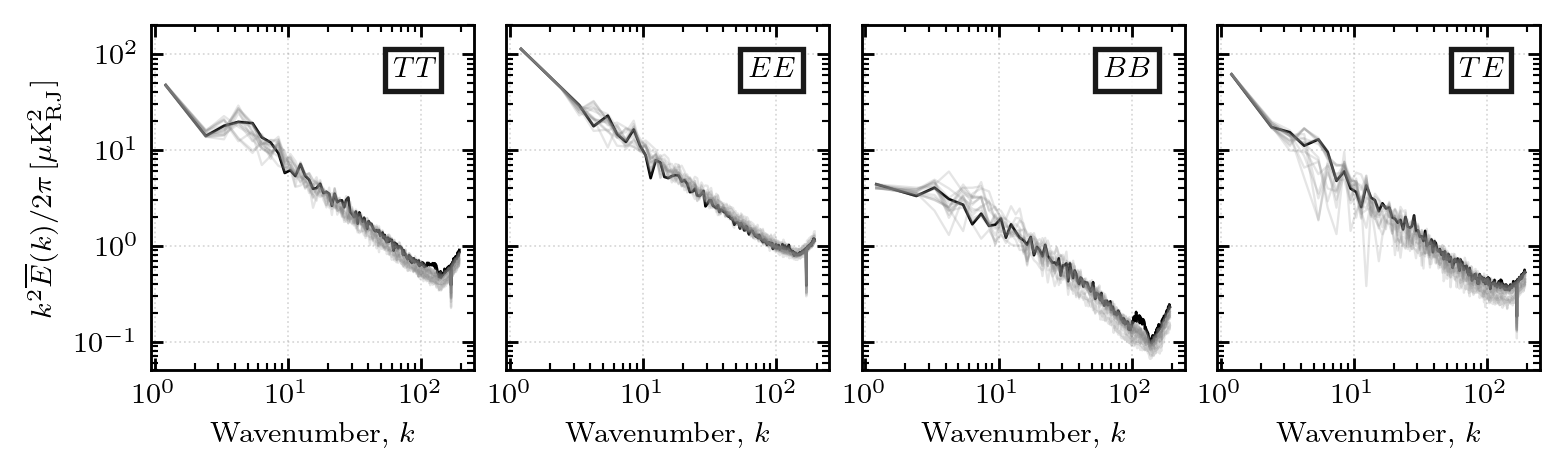

In [30]:
from src.utils import bbox_props

fig, ax = plt.subplots(1, 4, figsize=(3.5*2., 1.75), dpi=256)

# cols1 = sns.color_palette('rocket', n_colors=len(FEKS_TT)//4)
# cols2 = sns.color_palette('mako', n_colors=len(FEKS_TT)//4)
cols = ['gray' for _ in range(len(FEKS_TT))]
cols[0] = 'black'

for i in range(len(FEKS_TT)):
    if i == 0:
        ax[0].plot(FEKS_TT[i][0], FEKS_TT[i][0] * FEKS_TT[i][1], color=cols[i], linewidth=0.75)
        ax[1].plot(FEKS_EE[i][0], FEKS_EE[i][0] * FEKS_EE[i][1], color=cols[i], linewidth=0.75)
        ax[2].plot(FEKS_BB[i][0], FEKS_BB[i][0] * FEKS_BB[i][1], color=cols[i], linewidth=0.75)
        ax[3].plot(FEKS_TE[i][0], FEKS_TE[i][0] * FEKS_TE[i][1], color=cols[i], linewidth=0.75)
    else:
        ax[0].plot(FEKS_TT[i][0], FEKS_TT[i][0] * FEKS_TT[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[1].plot(FEKS_EE[i][0], FEKS_EE[i][0] * FEKS_EE[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[2].plot(FEKS_BB[i][0], FEKS_BB[i][0] * FEKS_BB[i][1], color=cols[i], alpha=0.2, linewidth=0.65)
        ax[3].plot(FEKS_TE[i][0], FEKS_TE[i][0] * FEKS_TE[i][1], color=cols[i], alpha=0.2, linewidth=0.65)

for axx in ax:
    pretty_axes(axx)
    axx.loglog()
    axx.set_xlabel('Wavenumber, $k$')
    axx.set_ylim((5e-2, 2e2))

ax[0].set_ylabel(r'$k^2 \overline{E}(k) / 2\pi\,[\mu \mathrm{K}_\mathrm{RJ}^2]$')
# ax[0].set_title('$TT$', fontsize=8.)
# ax[1].set_title('$EE$', fontsize=8.)
# ax[2].set_title('$BB$', fontsize=8.)
# ax[3].set_title('$TE$', fontsize=8.)

ax[0].text(0.75, 0.85, '$TT$', transform=ax[0].transAxes, color='black', bbox=bbox_props)
ax[1].text(0.75, 0.85, '$EE$', transform=ax[1].transAxes, color='black', bbox=bbox_props)
ax[2].text(0.75, 0.85, '$BB$', transform=ax[2].transAxes, color='black', bbox=bbox_props)
ax[3].text(0.75, 0.85, '$TE$', transform=ax[3].transAxes, color='black', bbox=bbox_props)

ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[3].set_yticklabels([])

fig.subplots_adjust(wspace=0.1)

fig.savefig('plots/example_highlat_spectra.pdf', pad_inches=0.1, bbox_inches='tight')
